In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import re
import os
import pandas as pd
import seaborn as sns
import scrublet as scr
import scipy as sp
import matplotlib as mpl
import gc
import scipy
import scvi
import tables
import numpy as np
import scipy.sparse as sp
import anndata
from typing import Dict, Optional

In [ ]:
mpl.rcParams.update(mpl.rcParamsDefault)
%matplotlib inline

# Load h5 data

In [ ]:
def dict_from_h5(file: str) -> Dict[str, np.ndarray]:
    d = {}
    with tables.open_file(file) as f:
        # read in everything
        for array in f.walk_nodes("/", "Array"):
            d[array.name] = array.read()
    return d


def _fill_adata_slots_automatically(adata, d):

    for key, value in d.items():
        try:
            if value is None:
                continue
            value = np.asarray(value)
            if len(value.shape) == 0:
                adata.uns[key] = value
            elif value.shape[0] == adata.shape[0]:
                if (len(value.shape) < 2) or (value.shape[1] < 2):
                    adata.obs[key] = value
                else:
                    adata.obsm[key] = value
            elif value.shape[0] == adata.shape[1]:
                if value.dtype.name.startswith('bytes'):
                    adata.var[key] = value.astype(str)
                else:
                    adata.var[key] = value
            else:
                adata.uns[key] = value
        except Exception:
            print('Unable to load data into AnnData: ', key, value, type(value))

def process_cellranger(sample, umi_filter=5):
    adata = sc.read_10x_mtx(sample)
    adata.var.rename(columns = {'gene_ids':'ENSEMBL'}, inplace = True)
    adata.var['SYMBOL'] = adata.var.index
    adata.var_names_make_unique()


    sc.pp.calculate_qc_metrics(adata, inplace=True)
    adata = adata[adata.obs['total_counts'] > umi_filter, :]
    adata.var['mt'] = [gene.lower().startswith('mt-')
                                         for gene in adata.var['SYMBOL']]
    adata.obs['mt_frac'] = (adata[:,adata.var['mt'].tolist()].X.sum(1).A.squeeze()
                                              / adata.obs['total_counts'])

    adata.obs['sample'] = sample
    adata.obs['barcode'] = adata.obs_names
    adata.obs_names = adata.obs['sample']+"_"+adata.obs['barcode']
    
    return adata

def apply_filters(adata, 
                  threshold_n_genes=500,
                  threshold_min_counts=1000,
                  threshold_mt=0.1, 
                  threshold_total_counts=100000):

    N_genes_filter = np.where(
        adata.obs.n_genes_by_counts > threshold_n_genes, 0, 1)
    min_counts_filter = np.where(
        adata.obs.total_counts > threshold_min_counts, 0, 1)
    pct_counts_mt_filter = np.where(
        adata.obs.mt_frac < threshold_mt, 0, 1)
    total_counts_filter = np.where(
        adata.obs.total_counts < threshold_total_counts, 0, 1)

    total_filtered = np.where(
        (adata.obs.mt_frac < threshold_mt) &
        (adata.obs.total_counts > min_counts_filter) &
        (adata.obs.n_genes_by_counts > threshold_n_genes) &
        (adata.obs.total_counts < threshold_total_counts), 0, 1)
    
    # save filtered information
    filter_summary = pd.DataFrame({'N_genes_filter':N_genes_filter,
                                   'min_total_UMI_filter':min_counts_filter,
                                  'pct_counts_mt_filter':pct_counts_mt_filter,
                                  'total_counts_filter':total_counts_filter,
                                  'total_filtered':total_filtered})\
                        .sum(axis=0)
    
    
    adata = adata[adata.obs.n_genes_by_counts > threshold_n_genes, :]
    adata = adata[adata.obs.total_counts > threshold_min_counts, :]
    adata = adata[adata.obs.mt_frac < threshold_mt, :]
    adata = adata[adata.obs.total_counts < threshold_total_counts, :]
    
    return adata, filter_summary

def run_scrublet(adata):
    if len(adata)>150:
        scrub = scr.Scrublet(adata.X)
        adata.obs['doublet_scores'], adata.obs['predicted_doublets'] = scrub.scrub_doublets()
        # doublet score properly computed; generally around ~0.25
        if hasattr(scrub, 'threshold_'):
            adata.obs['doublet_threshold'] = scrub.threshold_
        else:
            adata.obs['doublet_threshold'] = 0.25
    else:
        # if there is an issue with sample size, just keep all cells
        print('PCA issues likely due to N cells, \
        not detecting doublets')
        adata.obs['doublet_scores'] = 0
        adata.obs['doublet_threshold'] = 1
    
    filtered_doublets = np.where(adata.obs['doublet_scores']<adata.obs['doublet_threshold'],
                                0, 1).sum()
        
    return adata, filtered_doublets

## Load cell cycle genes
cc_path='../data/metadata/regev_lab_cell_cycle_genes.txt'
def calculate_cycle_score(adata, cc_genes_path = cc_path):
    
    cell_cycle_genes = [x.strip() for x in open(cc_genes_path)]

    # Split into 2 lists
    s_genes = cell_cycle_genes[:43]
    g2m_genes = cell_cycle_genes[43:]
    
    cc_genes = [x for x in cell_cycle_genes if x in adata.var_names]
    print(len(cc_genes))

    adata.layers['counts'] = adata.X.copy()

    # prep for cell cycle ID
    sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
    sc.pp.log1p(adata)
    sc.pp.scale(adata)

    # get cell cycle
    sc.tl.score_genes_cell_cycle(adata, 
                                 s_genes=s_genes, 
                                 g2m_genes=g2m_genes)
    
    return adata

def doublet_analysis(ad, sample, out_dir):
    
    # i.e. scanpy/seurat methods
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)
    sc.pp.highly_variable_genes(ad, 
                            min_mean=0.0125, 
                            max_mean=4, 
                            min_disp=0.1)
    selected = ad.var['highly_variable']
    ad = ad[:, selected].copy()
    
    # run scVI on single sample
    scvi.model.SCVI.setup_anndata(
        ad,
        layer="counts",
    )
    vae = scvi.model.SCVI(ad)
    vae.train()

    # run SOLO
    solo = scvi.external.SOLO.from_scvi_model(vae)
    solo.train()
    solo.predict()
    gc.collect()

    # export SOLO results
    scores = solo.predict(soft=True).reset_index(drop=True)
    solo_prediction = solo.predict(soft=False).reset_index(drop=True)
    ad.obs['solo_prediction'] = solo_prediction.tolist()
    ad.obs[['doublet', 'singlet']] = np.array(scores)

    # export posteriors, get latent for UMAP
    latent = vae.get_latent_representation()
    ad.obsm["X_scVI"] = latent

    # use scVI latent space for UMAP generation
    sc.pp.neighbors(ad, use_rep="X_scVI")
    sc.tl.leiden(ad, key_added="leiden_scVI")
    sc.tl.umap(ad, min_dist=0.3)

    # export UMAP for inspection
    sc.pl.umap(
        ad,
        color=["leiden_scVI", "doublet_scores", "doublet", "solo_prediction"],
        ncols=2,
        size=1,
        save = '_{}_doublet_scores.png'.format(sample), vmin=[0, 0, 0, 0],
        frameon=False)

    # export doublet details for each sample
    cell_id = ad.obs['sample'].astype(str)+'#'+ad.obs['barcode'].astype(str)
    ad.obs['cell_id'] = cell_id

    export_cols = ['cell_id', 'doublet_scores', 'doublet_threshold', 'doublet', 'singlet', 
            'solo_prediction', 'leiden_scVI']
    ad.obs[export_cols].to_csv(out_dir+'{}_doublet_calling_results.csv'.format(sample), index=None)

    # export embeddings
    np.save(out_dir+'{}_embeddings.npy'.format(sample), ad.obsm['X_scVI'])

In [ ]:
# Read donor metadata
sample_summary = pd.read_csv('../data/samplelist_phase_one.txt', sep='\t', header = None)
sample_summary = sample_summary.rename(columns={0:'sample', 1:'site_id'})

# Load sample directories
gbm_directory = '../data/'

file_paths = []
for root, dirs, files in os.walk(gbm_directory, topdown=False):
    for f in files:
        if 'cellbender_out_filtered.h5' in f:
                file_paths.append(root+'/cellbender_out/')

cellranger-arc201_count_adf395d2259f5577779c070f7ebe5b76


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/ipykernel_launcher.py:108: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.38
Detected doublet rate = 1.1%
Estimated detectable doublet fraction = 7.8%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 14.2%
Elapsed time: 13.3 seconds
94


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/ipykernel_launcher.py:158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 400/400: 100%|█████████████████████████████████████████████████████████| 400/400 [06:01<00:00,  1.04it/s, loss=4.88e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|█████████████████████████████████████████████████████████| 400/400 [06:01<00:00,  1.11it/s, loss=4.88e+03, v_num=1]
INFO     Creating doublets, preparing SOLO model.                                            


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 215/400:  54%|████████████████████████████████▎                           | 215/400 [02:42<02:19,  1.33it/s, loss=0.384, v_num=1]
Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.384. Signaling Trainer to stop.


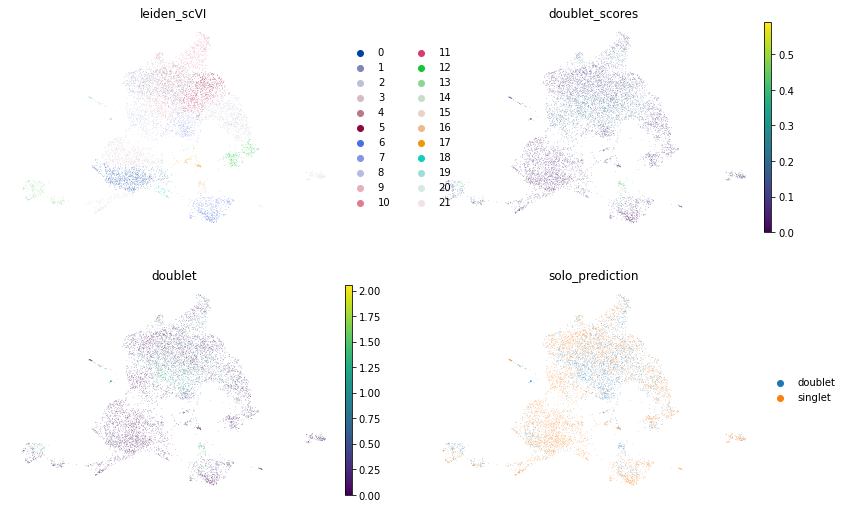

cellranger-arc201_count_6f84b951b528e6a96f5bfd94b2acbca8


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/ipykernel_launcher.py:108: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.73
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.7%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 5.7%
Elapsed time: 7.8 seconds
94


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/ipykernel_launcher.py:158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 400/400: 100%|█████████████████████████████████████████████████████████| 400/400 [04:20<00:00,  1.49it/s, loss=2.48e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|█████████████████████████████████████████████████████████| 400/400 [04:20<00:00,  1.54it/s, loss=2.48e+03, v_num=1]
INFO     Creating doublets, preparing SOLO model.                                            


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 283/400:  71%|███████████████████████████████████████████▏                 | 283/400 [02:36<01:04,  1.81it/s, loss=0.32, v_num=1]
Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.352. Signaling Trainer to stop.


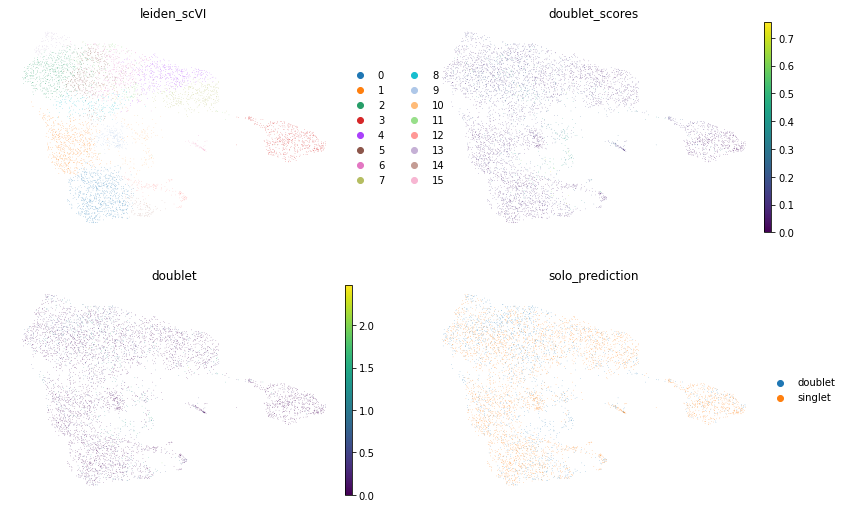

cellranger-arc201_count_cebf8d5a5a411edfd7e46db39aafbded


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/ipykernel_launcher.py:108: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.74
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.2%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 7.7%
Elapsed time: 9.4 seconds
94


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/ipykernel_launcher.py:158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 400/400: 100%|█████████████████████████████████████████████████████████| 400/400 [05:03<00:00,  1.30it/s, loss=2.96e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|█████████████████████████████████████████████████████████| 400/400 [05:03<00:00,  1.32it/s, loss=2.96e+03, v_num=1]
INFO     Creating doublets, preparing SOLO model.                                            


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 189/400:  47%|████████████████████████████▎                               | 189/400 [02:10<02:25,  1.45it/s, loss=0.373, v_num=1]
Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.383. Signaling Trainer to stop.


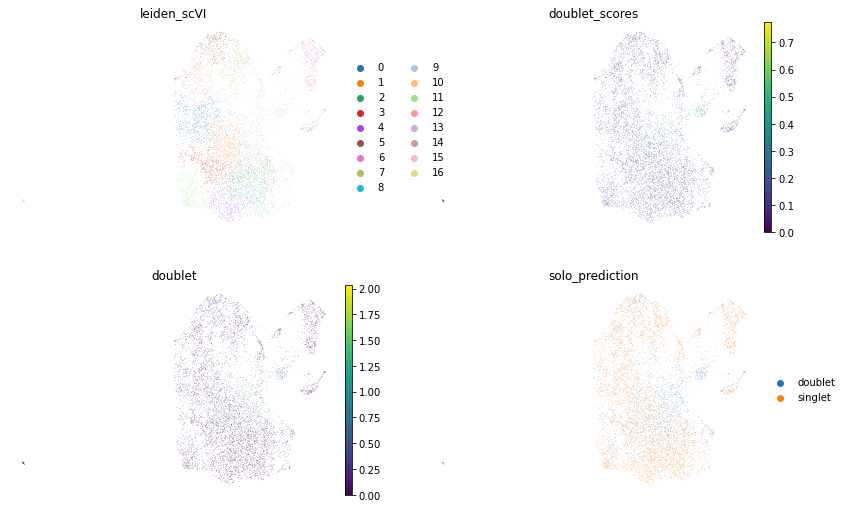

cellranger-arc201_count_f38d0ae00fdd7a3c470f4963e239a062


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/ipykernel_launcher.py:108: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.60
Detected doublet rate = 0.3%
Estimated detectable doublet fraction = 4.7%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 5.3%
Elapsed time: 1.6 seconds
94


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/ipykernel_launcher.py:158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 400/400: 100%|█████████████████████████████████████████████████████████| 400/400 [01:41<00:00,  3.94it/s, loss=1.48e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|█████████████████████████████████████████████████████████| 400/400 [01:41<00:00,  3.93it/s, loss=1.48e+03, v_num=1]
INFO     Creating doublets, preparing SOLO model.                                            


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 293/400:  73%|███████████████████████████████████████████▉                | 293/400 [01:01<00:22,  4.77it/s, loss=0.233, v_num=1]
Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.234. Signaling Trainer to stop.


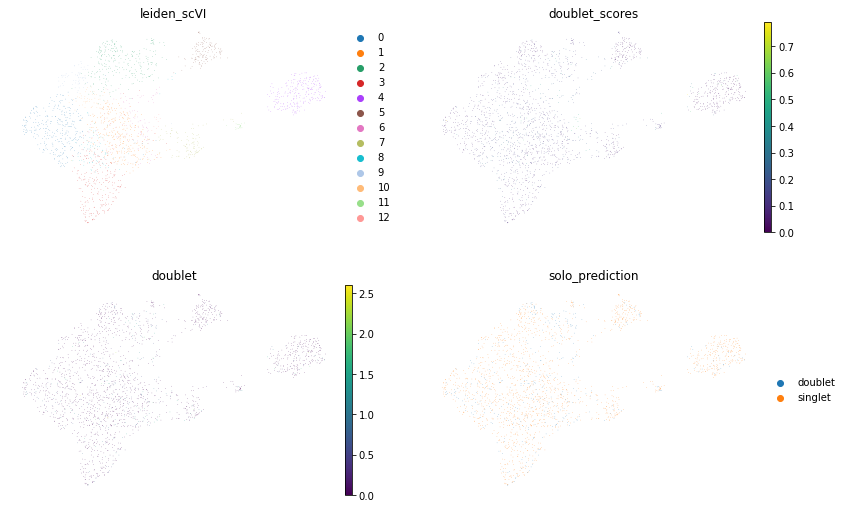

cellranger-arc201_count_6e71c80210b6a7e73d4c1e6603c3e5c8


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/ipykernel_launcher.py:108: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.32
Detected doublet rate = 4.5%
Estimated detectable doublet fraction = 31.9%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 14.1%
Elapsed time: 17.4 seconds
94


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/ipykernel_launcher.py:158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 400/400: 100%|█████████████████████████████████████████████████████████| 400/400 [08:36<00:00,  1.19s/it, loss=3.83e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|█████████████████████████████████████████████████████████| 400/400 [08:36<00:00,  1.29s/it, loss=3.83e+03, v_num=1]
INFO     Creating doublets, preparing SOLO model.                                            


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 192/400:  48%|████████████████████████████▊                               | 192/400 [03:27<03:44,  1.08s/it, loss=0.361, v_num=1]
Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.346. Signaling Trainer to stop.


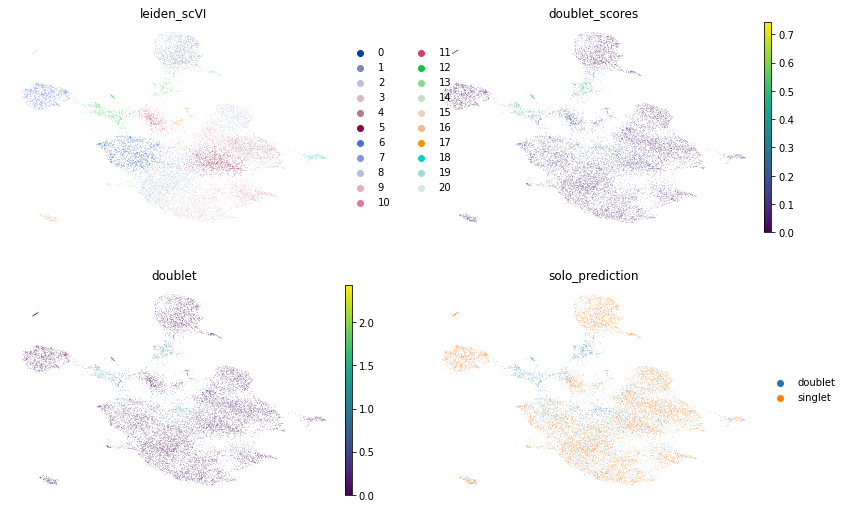

cellranger-arc201_count_e7ffb41b50cba2c725fbcd35d5dce194


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/ipykernel_launcher.py:108: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.71
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.1%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 8.7%
Elapsed time: 15.0 seconds
94


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/ipykernel_launcher.py:158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 400/400: 100%|██████████████████████████████████████████████████████████| 400/400 [07:17<00:00,  1.09s/it, loss=4.3e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████████████████████████████████████████████████████| 400/400 [07:17<00:00,  1.09s/it, loss=4.3e+03, v_num=1]
INFO     Creating doublets, preparing SOLO model.                                            


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 205/400:  51%|██████████████████████████████▋                             | 205/400 [03:11<03:02,  1.07it/s, loss=0.342, v_num=1]
Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.354. Signaling Trainer to stop.


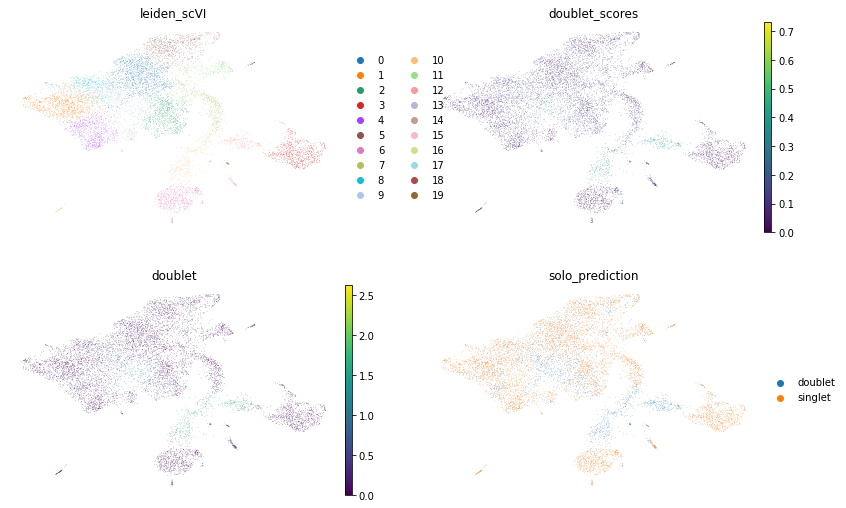

cellranger-arc201_count_772df8093cb58ddc07ffc786d42e191e


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/ipykernel_launcher.py:108: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.26
Detected doublet rate = 7.5%
Estimated detectable doublet fraction = 35.6%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 20.9%
Elapsed time: 6.0 seconds
94


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/ipykernel_launcher.py:158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Epoch 400/400: 100%|█████████████████████████████████████████████████████████| 400/400 [03:08<00:00,  2.12it/s, loss=4.23e+03, v_num=1]
INFO     Creating doublets, preparing SOLO model.                                            


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 400/400: 100%|████████████████████████████████████████████████████████████| 400/400 [02:42<00:00,  2.38it/s, loss=0.368, v_num=1]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|████████████████████████████████████████████████████████████| 400/400 [02:42<00:00,  2.46it/s, loss=0.368, v_num=1]


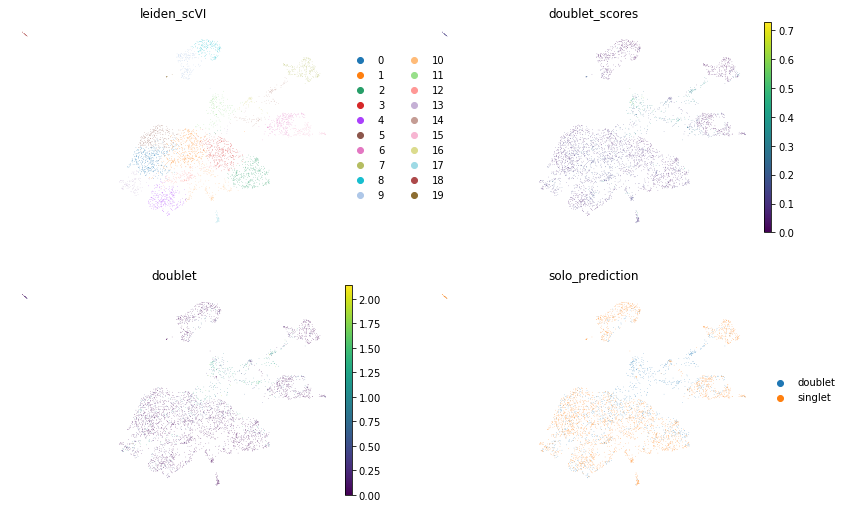

cellranger-arc201_count_0f559e5165fa855491042d3ac3811307


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/ipykernel_launcher.py:108: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.82
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.1%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 21.1%
Elapsed time: 16.9 seconds
94


/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/ipykernel_launcher.py:158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 321/400:  80%|██████████████████████████████████████████████▍           | 320/400 [08:19<02:08,  1.61s/it, loss=2.5e+03, v_num=1]

In [ ]:
ad_list = []
filter_list = []
doublet_list = []
raw_QC = []
for sample in file_paths:
    sample_id = re.sub('^.*cellranger(.*?)/cellbender_out/$', 
        'cellranger\\1', sample)
    print(sample_id)

    adata = process_cellranger(sample)
    raw_adata_obs = adata.obs
    raw_QC.append(raw_adata_obs)
    adata, filtered_summary = apply_filters(adata,
                                           threshold_total_counts=10000000)
    if len(adata.obs)>100:
        adata, filtered_doublets = run_scrublet(adata)
        adata = calculate_cycle_score(adata)
        adata.X = adata.layers['counts'].copy()
        
        doublet_analysis(adata, sample_id, 
                '../output/doublet_analysis/')

        ad_list.append(adata)
        filter_list.append(filtered_summary)
        doublet_list.append(filtered_doublets)

In [ ]:
import anndata as ad
adata = ad.concat(ad_list, merge = 'same')

In [ ]:
# check for expected samples
len(set(adata.obs['sample']))

167

In [ ]:
# Extract sampleID
pattern = '../data/(.*?)/cellbender_out/'
adata.obs['sample'] = [re.sub(pattern, 
                              '\\1', i) for i in adata.obs['sample']]

print(adata.shape)

# Add sample_summary metadata
adata.obs = adata.obs.reset_index()\
                                .merge(sample_summary, on = 'sample', how='left')\
                                .set_index('index')

print(adata.shape)

(1436505, 36601)
(1436505, 36601)


In [ ]:
# Parse donor IDs from sample names
adata.obs['donor_id'] = [re.sub('-.*$', '', str(i)) for i in adata.obs['site_id']]
adata = adata[adata.obs['donor_id']!='AT8',:] # REMOVE OLIGODENDROGLIOMA DONOR

# Get cell ID for cross-compatibility with ArchR
adata.obs['cell_id'] = adata.obs['sample'].astype(str)+'#'+adata.obs['barcode'].astype(str)

In [ ]:
adata.write_h5ad('../data/adata/GBM_LEAP_23_05_04_QC_no_doublet_removal.h5ad')